<a href="https://colab.research.google.com/github/safoura-banihashemi/predicting-online-news-popularity/blob/main/Predicting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, ChiSqSelector
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.classification import RandomForestClassifier, GBTClassifier, NaiveBayes, LogisticRegression
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.sql import functions as F

In [ ]:
!pip install pyspark

In [ ]:
import pyspark
from pyspark.sql import SparkSession

# Spark Session
spark = (
    SparkSession.builder
    .appName("OnlineNewsPopularity")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "50")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark version: {spark.version}\n")

Spark version: 4.0.2



## Data Loading & Exploration

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
online_news_popularity = fetch_ucirepo(id=332)

# data (as pandas dataframes)
X = online_news_popularity.data.features
y = online_news_popularity.data.targets

print(f"The number of samples: {X.shape[0]}")
print(f"The number of features: {X.shape[1]}")

The number of samples: 39644
The number of features: 58


In [ ]:
print(f"Feature list: {X.columns}")

Feature list: Index([' n_tokens_title', ' n_tokens_content', ' n_unique_tokens',
       ' n_non_stop_words', ' n_non_stop_unique_tokens', ' num_hrefs',
       ' num_self_hrefs', ' num_imgs', ' num_videos', ' average_token_length',
       ' num_keywords', ' data_channel_is_lifestyle',
       ' data_channel_is_entertainment', ' data_channel_is_bus',
       ' data_channel_is_socmed', ' data_channel_is_tech',
       ' data_channel_is_world', ' kw_min_min', ' kw_max_min', ' kw_avg_min',
       ' kw_min_max', ' kw_max_max', ' kw_avg_max', ' kw_min_avg',
       ' kw_max_avg', ' kw_avg_avg', ' self_reference_min_shares',
       ' self_reference_max_shares', ' self_reference_avg_sharess',
       ' weekday_is_monday', ' weekday_is_tuesday', ' weekday_is_wednesday',
       ' weekday_is_thursday', ' weekday_is_friday', ' weekday_is_saturday',
       ' weekday_is_sunday', ' is_weekend', ' LDA_00', ' LDA_01', ' LDA_02',
       ' LDA_03', ' LDA_04', ' global_subjectivity',
       ' global_sentiment_p

In [ ]:
# Merge into one pandas frame, then convert to Spark
df = pd.concat([X, y], axis=1)

# Strip whitespace from column names
df.columns = df.columns.str.strip()

In [ ]:
# Print some samples
df.head(5)

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [ ]:
# Get a statistical summary (min, max, mean, standard deviation)
df.describe()

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
count,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,...,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000
mean,10.398749,546.514731,0.548216,0.996469,0.689175,10.883690,3.293638,4.544143,1.249874,4.548239,...,0.095446,0.756728,-0.259524,-0.521944,-0.107500,0.282353,0.071425,0.341843,0.156064,3395.380184
std,2.114037,471.107508,3.520708,5.231231,3.264816,11.332017,3.855141,8.309434,4.107855,0.844406,...,0.071315,0.247786,0.127726,0.290290,0.095373,0.324247,0.265450,0.188791,0.226294,11626.950749
min,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,1.000000
25%,9.000000,246.000000,0.470870,1.000000,0.625739,4.000000,1.000000,1.000000,0.000000,4.478404,...,0.050000,0.600000,-0.328383,-0.700000,-0.125000,0.000000,0.000000,0.166667,0.000000,946.000000
50%,10.000000,409.000000,0.539226,1.000000,0.690476,8.000000,3.000000,1.000000,0.000000,4.664082,...,0.100000,0.800000,-0.253333,-0.500000,-0.100000,0.150000,0.000000,0.500000,0.000000,1400.000000
75%,12.000000,716.000000,0.608696,1.000000,0.754630,14.000000,4.000000,4.000000,1.000000,4.854839,...,0.100000,1.000000,-0.186905,-0.300000,-0.050000,0.500000,0.150000,0.500000,0.250000,2800.000000
max,23.000000,8474.000000,701.000000,1042.000000,650.000000,304.000000,116.000000,128.000000,91.000000,8.041534,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.500000,1.000000,843300.000000


In [ ]:
# Check for any nulls across the entire dataset at once
print(f"Total missing values: {df.isnull().sum().sum()}")

Total missing values: 0


In [ ]:
# Check if there are any duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [ ]:
# Convert to float
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

# Count difference
deleted_rows = len(X) - len(df)
print(f"Number of deleted samples: {deleted_rows}")

Number of deleted samples: 0


## Convert to binary classification task

In [ ]:
# Calculate the median of the target variable
median_shares = df['shares'].median()
print(f"The median number of shares is: {median_shares}")

The median number of shares is: 1400.0


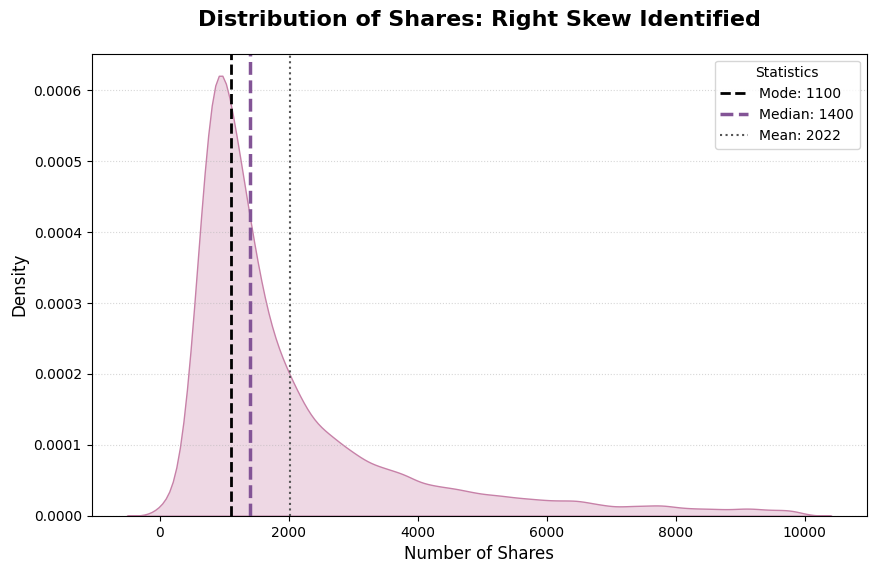

In [ ]:
# Filter out
filtered_y = df[df['shares'] < 10000]['shares'].copy()

# Calculate the statistical points
mean_val = filtered_y.mean()
median_val = filtered_y.median() # This should be ~1400
mode_val = filtered_y.mode()[0]  # Take the first mode if multiple exist

# Initialize the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Generate the Smooth Curve
sns.kdeplot(filtered_y, color="#C781A8", fill=True, alpha=0.3, bw_adjust=0.8)

# Add vertical dashed lines for statistical points
# Mode line (Black, thick)
ax.axvline(mode_val, color='black', linestyle='--', linewidth=2, label=f'Mode: {mode_val:.0f}')
# Median line (Purple, thick)
ax.axvline(median_val, color='#835496', linestyle='--', linewidth=2.5, label=f'Median: {median_val:.0f}')
# Mean line (Dark grey, thin)
ax.axvline(mean_val, color='#555555', linestyle=':', linewidth=1.5, label=f'Mean: {mean_val:.0f}')

# Formatting & Labels
ax.set_title("Distribution of Shares: Right Skew Identified", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Number of Shares", fontsize=12)
ax.set_ylabel("Density", fontsize=12)

# Set the background to clean white and add subtle gridlines
ax.set_facecolor('white')
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Place the legend
ax.legend(title="Statistics")

plt.show()

In [ ]:
# Binary label: popular = shares >= 1400 (median threshold)
THRESHOLD = 1400
df["label"] = (df["shares"] >= THRESHOLD).astype(int)
df.drop(columns=["shares"], inplace=True)

counts = df["label"].value_counts()
total = len(df)

print(counts)
print(f"\nPopular news:   {(counts[1]/total):.2%}")
print(f"\nUnpopular news: {(counts[0]/total):.2%}")

label
1    21154
0    18490
Name: count, dtype: int64

Popular news:   53.36%

Unpopular news: 46.64%


In [ ]:
# Print some samples
df.head(5)

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,label
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,0
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,0
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1
3,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,0
4,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,0


In [ ]:
# Push to Spark
sdf = spark.createDataFrame(df)
sdf.printSchema()
print(f"Total rows in Spark df: {sdf.count()}")

root
 |-- n_tokens_title: double (nullable = true)
 |-- n_tokens_content: double (nullable = true)
 |-- n_unique_tokens: double (nullable = true)
 |-- n_non_stop_words: double (nullable = true)
 |-- n_non_stop_unique_tokens: double (nullable = true)
 |-- num_hrefs: double (nullable = true)
 |-- num_self_hrefs: double (nullable = true)
 |-- num_imgs: double (nullable = true)
 |-- num_videos: double (nullable = true)
 |-- average_token_length: double (nullable = true)
 |-- num_keywords: double (nullable = true)
 |-- data_channel_is_lifestyle: double (nullable = true)
 |-- data_channel_is_entertainment: double (nullable = true)
 |-- data_channel_is_bus: double (nullable = true)
 |-- data_channel_is_socmed: double (nullable = true)
 |-- data_channel_is_tech: double (nullable = true)
 |-- data_channel_is_world: double (nullable = true)
 |-- kw_min_min: double (nullable = true)
 |-- kw_max_min: double (nullable = true)
 |-- kw_avg_min: double (nullable = true)
 |-- kw_min_max: double (nullab

## Exploratory Data Analysis (EDA)

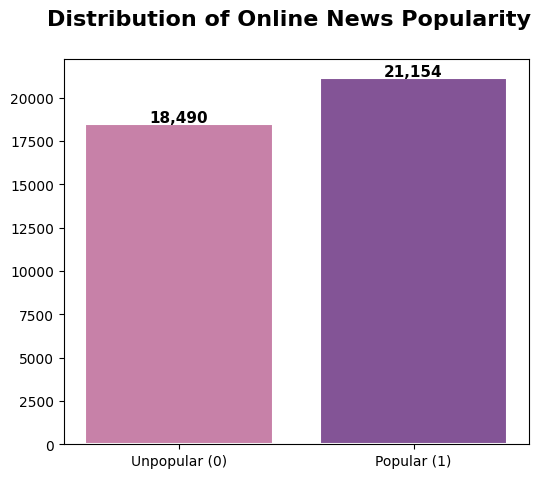

In [ ]:
# Initialize the plot
fig, ax = plt.subplots(figsize=(6, 5))
PALETTE = ["#C781A8", "#835496"]

fig.suptitle("Distribution of Online News Popularity", fontsize=16, fontweight="bold")

counts = df["label"].value_counts().sort_index()
ax.bar(["Unpopular (0)", "Popular (1)"], counts.values,
            color=PALETTE, edgecolor="white", linewidth=1.5)
for i, v in enumerate(counts.values):
    ax.text(i, v + 100, f"{v:,}", ha="center", fontsize=11, fontweight="bold")

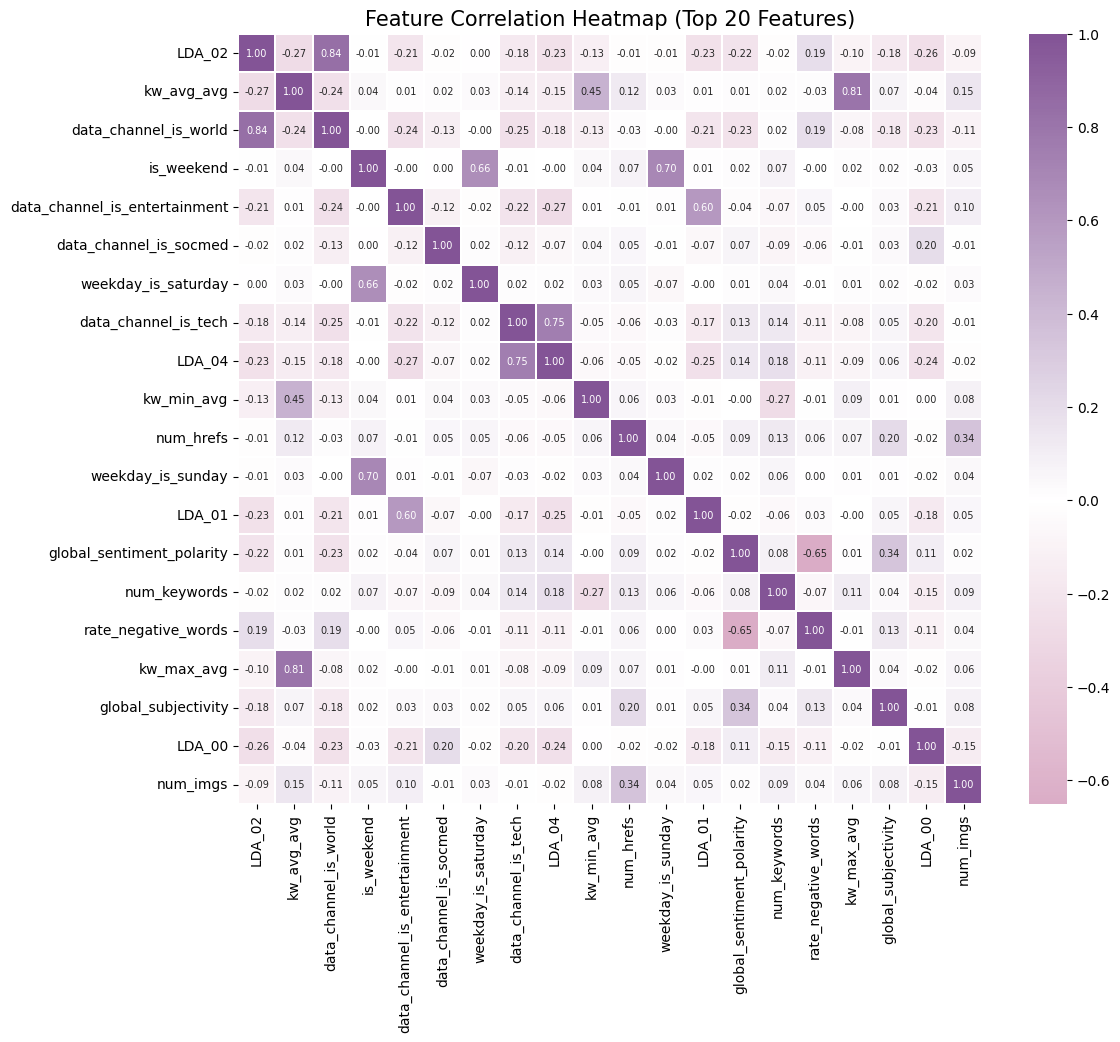

In [ ]:
# feature matrix
feature_list = [col for col in df.columns if col != "label"]

# Identify top 20 features correlated with the label
label_corr = df[feature_list].corrwith(df["label"]).abs().nlargest(20)
top20_features = label_corr.index.tolist()

# Create the Heatmap
colors = ["#C781A8", "#FFFFFF", "#835496"]
cmap = LinearSegmentedColormap.from_list("custom", colors)

plt.figure(figsize=(12, 10))

# Calculate correlation matrix for only the top 20 features
sub_corr = df[top20_features].corr()

sns.heatmap(sub_corr,
            cmap=cmap,
            center=0,
            linewidths=0.3,
            annot=True,     # to see the numbers
            fmt=".2f",      # Rounds numbers to 2 decimal places
            annot_kws={"size": 7})

plt.title("Feature Correlation Heatmap (Top 20 Features)", fontsize=15)
plt.show()

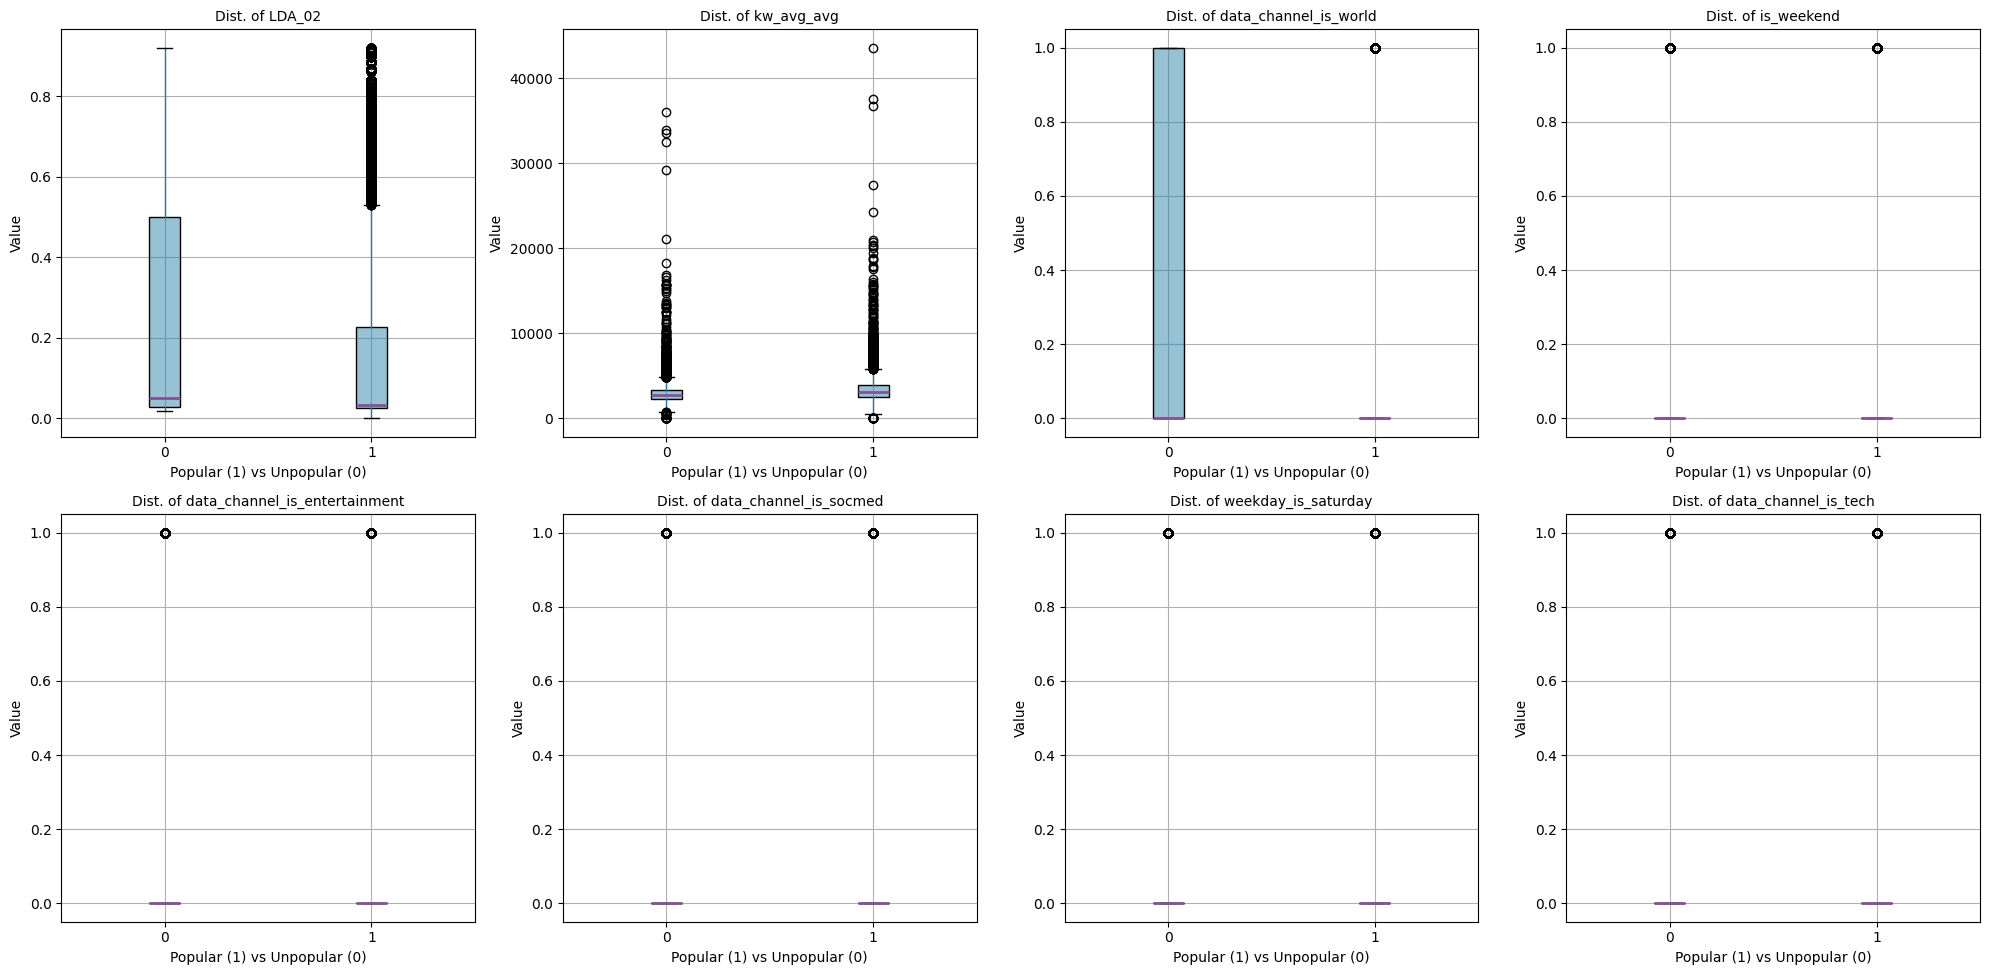

In [ ]:
# ۱. انتخاب ۸ ویژگی برتر بر اساس همبستگی
top8 = (
    df.drop(columns=["label"])
    .corrwith(df["label"])
    .abs()
    .nlargest(8)
    .index.tolist()
)

# ۲. آماده‌سازی صفحه رسم
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# ۳. رسم نمودارهای جعبه‌ای (Boxplot)
for ax, feat in zip(axes.ravel(), top8):
    # رسم باکس‌پلات تفکیک شده بر اساس برچسب
    df.boxplot(column=feat, by="label", ax=ax, patch_artist=True,
                  boxprops=dict(facecolor="#2E86AB80"), # رنگ آبی شفاف برای جعبه
                  medianprops=dict(color="#835496", linewidth=2)) # استفاده از بنفش پالت شما برای میانه

    ax.set_title(f"Dist. of {feat}", fontsize=10)
    ax.set_xlabel("Popular (1) vs Unpopular (0)")
    ax.set_ylabel("Value")

# ۴. تنظیمات نهایی ظاهر
plt.suptitle("Feature Distribution by Class (Top-8 Correlated Features)",
             fontsize=16, fontweight="bold", y=1.02)
fig.get_figure().suptitle("") # حذف تیتر خودکار پانداز برای جلوگیری از تداخل
plt.tight_layout()

# ۵. نمایش خروجی (حیاتی)
plt.show()

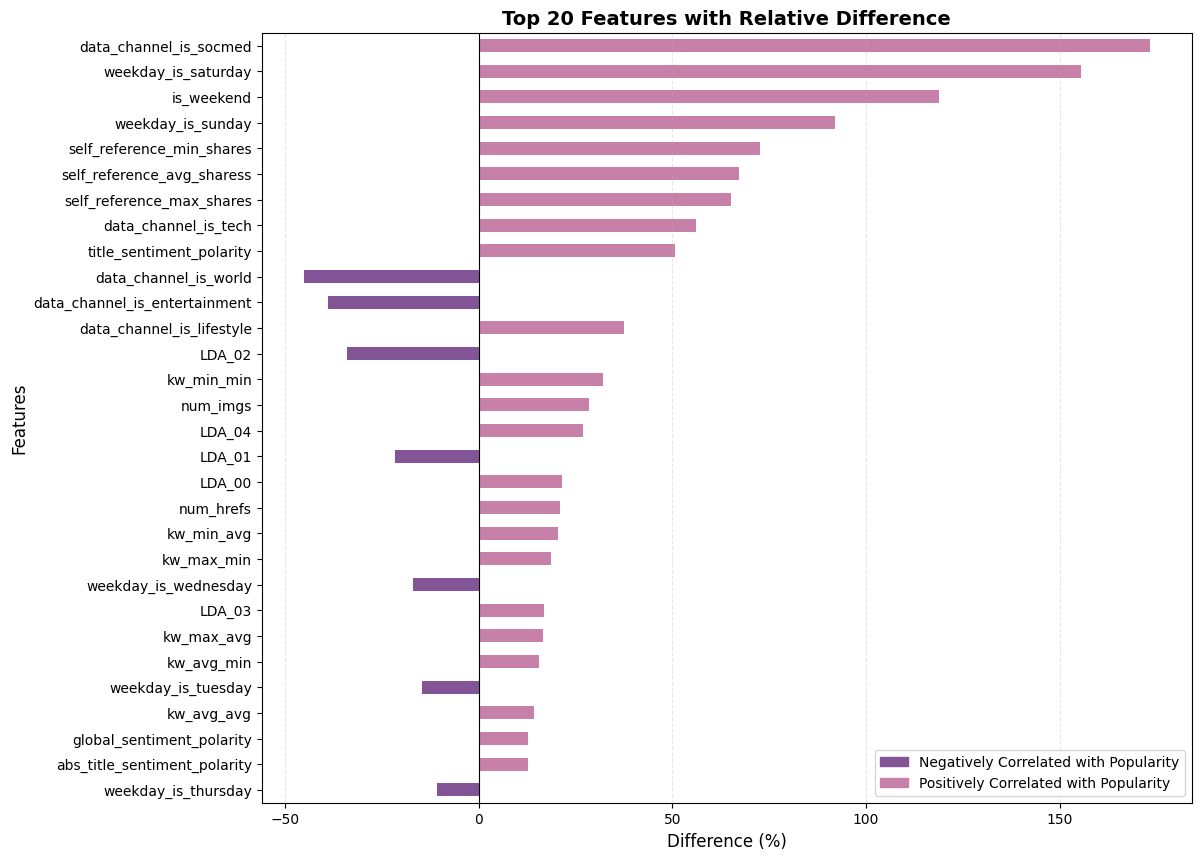

In [ ]:
unpopular = df[df['label'] == 0].mean()
popular = df[df['label'] == 1].mean()

class_diff = pd.DataFrame({
    'Mean_Unpopular': unpopular,
    'Mean_Popular': popular
})

class_diff['Diff (%)'] = ((class_diff['Mean_Popular'] - class_diff['Mean_Unpopular']) / class_diff['Mean_Unpopular']) * 100
class_diff['Abs_Diff'] = class_diff['Diff (%)'].abs()

# Delete label if exist (it is not feature)
if 'label' in class_diff.index:
    class_diff = class_diff.drop('label')

# Initialize the plot
plt.figure(figsize=(12, 10))

# Identify top 20 features with absolute difference
top20_diff = class_diff.sort_values('Abs_Diff', ascending=False).head(30)

# Set color
colors = np.where(top20_diff['Diff (%)'] > 0, PALETTE[0], PALETTE[1])

#
top20_diff['Diff (%)'].plot(kind='barh', color=colors)

#
plt.title('Top 20 Features with Relative Difference', fontsize=14, fontweight='bold')
plt.xlabel('Difference (%)', fontsize=12)
plt.ylabel('Features', fontsize=12)

#
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.3)

#
plt.gca().invert_yaxis()

# ایجاد راهنمای نمودار متناسب با پالت صورتی و بنفش
purple_patch = mpatches.Patch(color='#835496', label='Negatively Correlated with Popularity')
pink_patch = mpatches.Patch(color='#C781A8', label='Positively Correlated with Popularity')

# اضافه کردن به نمودار
plt.legend(handles=[purple_patch, pink_patch], loc='lower right', fontsize=10)

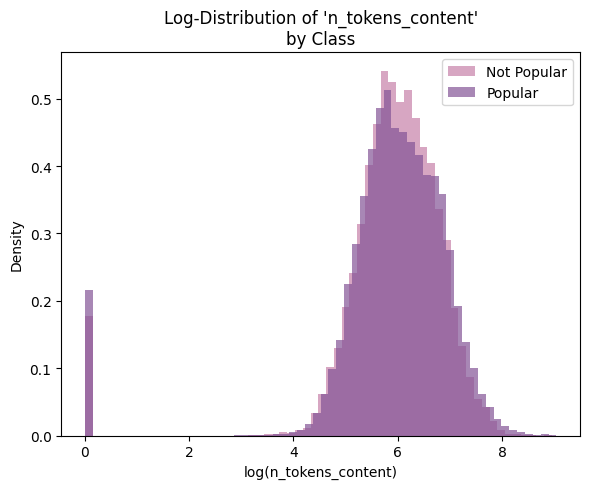

In [ ]:
# Initialize the plot
fig, ax = plt.subplots(figsize=(6, 5))

key_feat = "n_tokens_content"

# اعمال لگاریتم روی داده‌ها هنگام رسم برای نمایش بهتر
ax.hist(
    np.log1p(df.loc[df["label"] == 0, key_feat]), # استفاده از log1p
    bins=60, alpha=0.7, color=PALETTE[0], label="Not Popular", density=True
)
ax.hist(
    np.log1p(df.loc[df["label"] == 1, key_feat]), # استفاده از log1p
    bins=60, alpha=0.7, color=PALETTE[1], label="Popular", density=True
)

ax.set_title(f"Log-Distribution of '{key_feat}'\nby Class")
ax.set_xlabel(f"log({key_feat})")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.show() # نمایش نمودار قبل از بستن

## Feature selection

In [ ]:
feature_cols = [c for c in sdf.columns if c != "label"]

# Keep features with |corr(feature, label)| > 0.01
corr_with_label = (
    df.drop(columns=["label"])
    .corrwith(df["label"])
    .abs()
    .sort_values(ascending=False)
)

pre_filtered = corr_with_label[corr_with_label > 0.01].index.tolist()
print(f"Pre-filter (|corr| > 0.01): {len(feature_cols)} → {len(pre_filtered)} features")

Pre-filter (|corr| > 0.01): 58 → 48 features


In [ ]:
len(df.columns)

59

In [ ]:
# ── 4b. Chi-Squared selector in Spark ─────────────────────
# We use ChiSqSelector and sweep over numTopFeatures = [20, 30, 40, 50, 58]
# and pick the best via a quick LR cross-val on a 20 % sample.

sdf_sample = sdf.sample(fraction=0.2, seed=42)

assembler_full = VectorAssembler(
    inputCols=pre_filtered, outputCol="raw_features", handleInvalid="skip"
)
scaler_temp = StandardScaler(
    inputCol="raw_features", outputCol="scaled_features", withMean=True, withStd=True
)

best_k, best_auc = 0, 0.0
k_candidates = [20, 30, 40, 50, 58]
auc_scores = {}

print("\nSweeping number of features via ChiSqSelector + quick LR AUC:")
for k in k_candidates:
    selector = ChiSqSelector(
        numTopFeatures=k,
        featuresCol="raw_features",
        outputCol="sel_features",
        labelCol="label"
    )
    lr_tmp = LogisticRegression(
        featuresCol="sel_features", labelCol="label", maxIter=20
    )
    pipe_tmp = Pipeline(stages=[assembler_full, selector, lr_tmp])
    train_s, val_s = sdf_sample.randomSplit([0.8, 0.2], seed=42)
    model_tmp = pipe_tmp.fit(train_s)
    preds_tmp = model_tmp.transform(val_s)
    ev = BinaryClassificationEvaluator(
        labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
    )
    auc = ev.evaluate(preds_tmp)
    auc_scores[k] = auc
    print(f"  k={k:3d}  AUC={auc:.4f}")
    if auc > (best_auc + 0.0001):
        best_auc, best_k = auc, k

print(f"\n✔ Best k = {best_k}  (AUC = {best_auc:.4f})")
print(
    f"\nReasoning: k={best_k} achieves the highest validation AUC with the fewest "
    f"features. Fewer features reduce noise, training time, and overfitting. "
    f"The gain from adding more features plateaus past this point."
)


Sweeping number of features via ChiSqSelector + quick LR AUC:
  k= 20  AUC=0.6698
  k= 30  AUC=0.6734
  k= 40  AUC=0.6897
  k= 50  AUC=0.7055
  k= 58  AUC=0.7055

✔ Best k = 50  (AUC = 0.7055)

Reasoning: k=50 achieves the highest validation AUC with the fewest features. Fewer features reduce noise, training time, and overfitting. The gain from adding more features plateaus past this point.


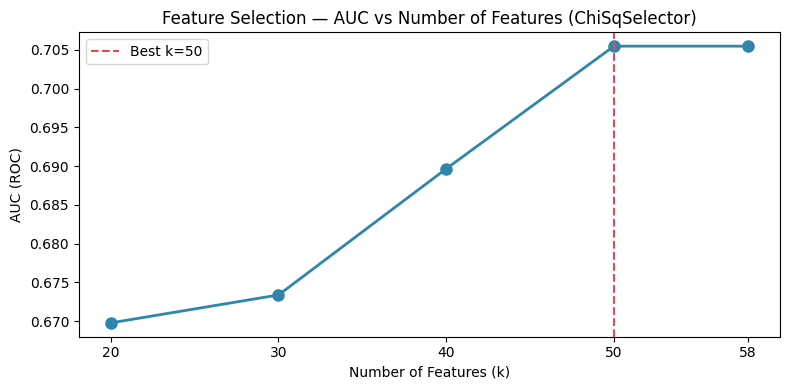

In [ ]:
# ── 4c. Plot AUC vs k ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(auc_scores.keys()), list(auc_scores.values()),
        marker="o", color="#2E86AB", linewidth=2, markersize=8)
ax.axvline(best_k, color="#E84855", linestyle="--", label=f"Best k={best_k}")
ax.set_title("Feature Selection — AUC vs Number of Features (ChiSqSelector)")
ax.set_xlabel("Number of Features (k)")
ax.set_ylabel("AUC (ROC)")
ax.legend()
ax.set_xticks(k_candidates)
plt.tight_layout()
plt.show()


In [ ]:
# ── 4d. Build final assembler + selector ──────────────────
assembler = VectorAssembler(
    inputCols=pre_filtered, outputCol="raw_features", handleInvalid="skip"
)
scaler = StandardScaler(
    inputCol="raw_features", outputCol="scaled_features", withMean=True, withStd=True
)
selector_final = ChiSqSelector(
    numTopFeatures=best_k,
    featuresCol="raw_features",
    outputCol="features",
    labelCol="label"
)

## Rolling-Window Time-Series Split

Total rows   : 39,644
Window size  : 23,786
Step size    : 3,964
Fold 1: train_n=23786  test_n=3964  
Fold 2: train_n=23786  test_n=3964  
Fold 3: train_n=23786  test_n=3964  


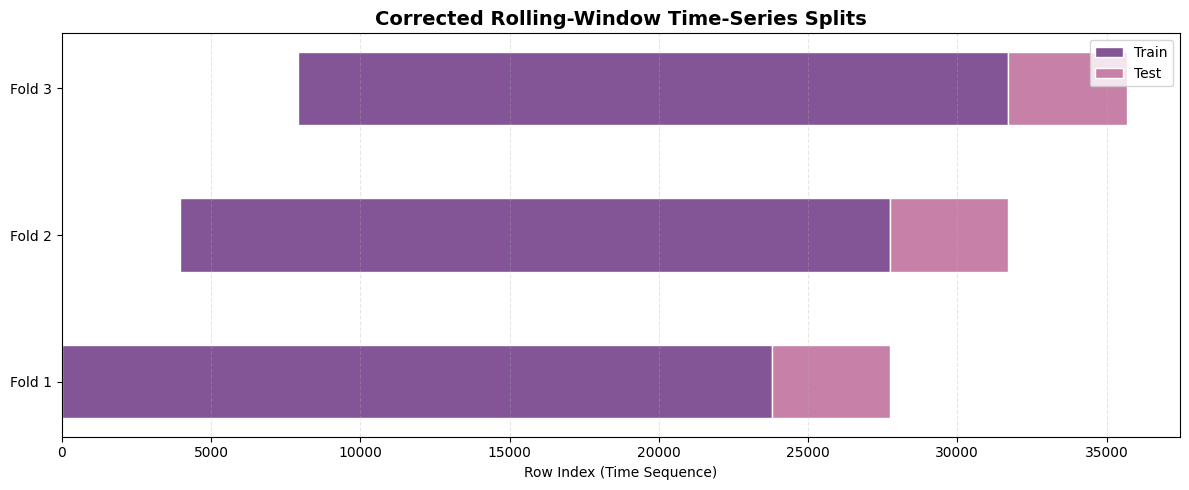

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql import Window
import matplotlib.pyplot as plt

# ۱. ایجاد شناسه زمانی پیوسته (جایگزین کردن روش قبلی برای حل خطا)
# این بخش تضمین می‌کند که ردیف‌ها از 0 تا N چیده شده‌اند و فولدها خالی نمی‌مانند
windowSpec = Window.orderBy(F.lit(1))
sdf = sdf.withColumn("time_idx", F.row_number().over(windowSpec) - 1)

total_rows = sdf.count()

# ۲. تنظیم پارامترهای پنجره لغزان
WINDOW_FRAC = 0.60
STEP_FRAC   = 0.10
N_SPLITS    = 3

window_size = int(total_rows * WINDOW_FRAC)
step_size   = int(total_rows * STEP_FRAC)

print(f"Total rows   : {total_rows:,}")
print(f"Window size  : {window_size:,}")
print(f"Step size    : {step_size:,}")

# ۳. ساخت فولدها (Train & Test Pairs)
splits = []
for i in range(N_SPLITS):
    train_start = i * step_size
    train_end   = train_start + window_size
    test_start  = train_end
    test_end    = test_start + step_size

    # فیلتر کردن دقیق داده‌ها بر اساس ایندکس‌های پیوسته
    train_fold = sdf.filter((F.col("time_idx") >= train_start) & (F.col("time_idx") < train_end))
    test_fold  = sdf.filter((F.col("time_idx") >= test_start) & (F.col("time_idx") < test_end))

    splits.append((train_fold, test_fold))

    print(f"Fold {i+1}: train_n={train_fold.count():<6} test_n={test_fold.count():<6}")

# ۴. رسم نمودار با پالت رنگی اختصاصی شما
fig, ax = plt.subplots(figsize=(12, 5))
colors_tr = "#835496" # بنفش برای آموزش
colors_te = "#C781A8" # صورتی برای تست

for i, (tr, te) in enumerate(splits):
    # دریافت مقادیر برای رسم نوارها
    tr_stats = tr.select(F.min("time_idx"), F.max("time_idx")).collect()[0]
    te_stats = te.select(F.min("time_idx"), F.max("time_idx")).collect()[0]

    tr_min, tr_max = tr_stats[0], tr_stats[1]
    te_min, te_max = te_stats[0], te_stats[1]

    # رسم نوار آموزش
    ax.barh(i, tr_max - tr_min, left=tr_min, height=0.5, color=colors_tr,
            edgecolor='white', label="Train" if i == 0 else "")

    # رسم نوار تست (اگر خالی نباشد)
    if te_max is not None:
        ax.barh(i, te_max - te_min, left=te_min, height=0.5, color=colors_te,
                edgecolor='white', label="Test" if i == 0 else "")

# ۵. تنظیمات نهایی ظاهری
ax.set_yticks(range(N_SPLITS))
ax.set_yticklabels([f"Fold {i+1}" for i in range(N_SPLITS)])
ax.set_xlabel("Row Index (Time Sequence)")
ax.set_title("Corrected Rolling-Window Time-Series Splits", fontsize=14, fontweight="bold")
ax.legend(loc='upper right')
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Model Definitions & Grid Search

In [ ]:
# Shared preprocessing pipeline stages
pre_stages = [assembler, selector_final]   # raw → selected features

In [ ]:
# ── Model configs ─────────────────────────────────────────
# Each entry: (name, estimator, param_grid, featuresCol)
# NaiveBayes requires non-negative features → we use raw (non-scaled)
# All others use the ChiSq-selected feature vector directly.

rf = RandomForestClassifier(
    featuresCol="features", labelCol="label", seed=42
)
rf_grid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees,      [50, 100])
    .addGrid(rf.maxDepth,      [5, 10])
    .addGrid(rf.minInstancesPerNode, [1, 5])
    .build()
)

gbt = GBTClassifier(
    featuresCol="features", labelCol="label", seed=42, maxIter=50
)
gbt_grid = (
    ParamGridBuilder()
    .addGrid(gbt.maxDepth, [3, 5])
    .addGrid(gbt.stepSize, [0.05, 0.1])
    .build()
)

nb = NaiveBayes(
    featuresCol="features", labelCol="label", modelType="multinomial"
)
# NaiveBayes needs non-negative features; we shift the selected vector
# For simplicity in this pipeline we use a MinMax-like offset inside
# a column rename; easier: just keep raw features clipped to >= 0.
# We rebuild a separate assembler that clips negatives to 0.
assembler_nb = VectorAssembler(
    inputCols=pre_filtered, outputCol="raw_features", handleInvalid="skip"
)

# Custom ChiSqSelector on non-negative (abs) features for NB
def make_nb_pipeline():
    """NaiveBayes needs non-negative values. We use the absolute-value trick
    via a SQL expression on each column before assembly."""
    abs_cols = [f"abs_{c}" for c in pre_filtered]
    # We'll create abs columns in the dataframe on-the-fly
    return abs_cols

abs_cols = make_nb_pipeline()

nb_grid = (
    ParamGridBuilder()
    .addGrid(nb.smoothing, [0.5, 1.0, 2.0])
    .build()
)

lr = LogisticRegression(
    featuresCol="features", labelCol="label", maxIter=100
)
lr_grid = (
    ParamGridBuilder()
    .addGrid(lr.regParam,      [0.01, 0.1, 0.5])
    .addGrid(lr.elasticNetParam, [0.0, 0.5])
    .build()
)

model_configs = [
    ("Random Forest",        rf,  rf_grid),
    ("Gradient Boosted Tree",gbt, gbt_grid),
    ("Logistic Regression",  lr,  lr_grid),
]
# NaiveBayes handled separately below